# ResNet-18 Phase 2: Joint Training (Mask + Classifier from Scratch)

## Overview

**Research Question:** What frequency preferences are built into the ResNet-18 architecture?

**Approach:** Input Image → FFT → Learnable 2D Frequency Mask → IFFT → Trainable ResNet-18 (from scratch)

**Key Differences from Phase 1:**
- **Phase 1:** Pre-trained classifier (frozen) - reveals what the model *learned* from ImageNet
- **Phase 2:** Random initialized classifier (trainable) - reveals *architectural* frequency preferences

**Expected Outcome:** If Phase 2 mask looks similar to Phase 1, the preference is architectural.

---

## 1. Setup and Imports

In [1]:
import sys
import os

# Add project root to path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/bab61wot/VIT/SIM2REAL


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path
import time

# Import project modules
from frequency.transforms import apply_fft, apply_ifft
from frequency.mask import Learnable2DFrequencyMask

print("Imports successful")

Imports successful


In [4]:
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce GTX 1060 6GB
Memory: 6.36 GB


## 2. Load Dataset

Loading the pre-cached ImageNet subset (same as Phase 1)

In [5]:
from datasets import load_from_disk
from torchvision import transforms
from data.dataset import HFImageNetDataset

# Configuration
CACHE_PATH = os.path.join(PROJECT_ROOT, "data", "imagenet_25k_cache")
BATCH_SIZE = 64

print(f"Loading dataset from {CACHE_PATH}...")
imagenet_subset = load_from_disk(CACHE_PATH)
print(f"Loaded {len(imagenet_subset):,} images")

# Setup transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create PyTorch dataset and dataloader
dataset = HFImageNetDataset(imagenet_subset, transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # Shuffle for training
    num_workers=0,
    pin_memory=True
)

print(f"DataLoader created: {len(dataloader)} batches of {BATCH_SIZE}")

Loading dataset from /home/bab61wot/VIT/SIM2REAL/data/imagenet_25k_cache...
Loaded 25,000 images
DataLoader created: 391 batches of 64


## 3. Create Joint Training Pipeline

In [6]:
class JointTrainingPipeline(nn.Module):
    """
    Phase 2 Pipeline: Both frequency mask AND classifier are trainable.
    """
    
    def __init__(self, classifier, image_size=224):
        super().__init__()
        
        self.classifier = classifier
        for param in self.classifier.parameters():
            param.requires_grad = True
        
        self.freq_mask = Learnable2DFrequencyMask(
            image_size=image_size,
            init_value=1.0,
            init_std=0.1
        )
        
        mask_params = sum(p.numel() for p in self.freq_mask.parameters())
        classifier_params = sum(p.numel() for p in self.classifier.parameters())
        
        print(f"\nJointTrainingPipeline created:")
        print(f"  Frequency mask: {mask_params:,} trainable params")
        print(f"  Classifier: {classifier_params:,} trainable params")
        print(f"  Total: {mask_params + classifier_params:,} trainable params")
    
    def forward(self, images):
        fft_result = apply_fft(images)
        masked_fft = self.freq_mask(fft_result)
        reconstructed = apply_ifft(masked_fft)
        outputs = self.classifier(reconstructed)
        return outputs, reconstructed
    
    def get_mask_params(self):
        return self.freq_mask.parameters()
    
    def get_classifier_params(self):
        return self.classifier.parameters()
    
    def get_mask_visualization(self):
        return self.freq_mask.get_mask_visualization()

In [7]:
# Load ResNet-18 with RANDOM initialization (no pretrained weights)
print("Loading ResNet-18 with random initialization (NO pretrained weights)...")
classifier = models.resnet18(weights=None, num_classes=1000)
print(f"  Total parameters: {sum(p.numel() for p in classifier.parameters()):,}")

# Create pipeline
pipeline = JointTrainingPipeline(classifier, image_size=224)
pipeline = pipeline.to(device)

print(f"\nPipeline moved to {device}")

Loading ResNet-18 with random initialization (NO pretrained weights)...
  Total parameters: 11,689,512

JointTrainingPipeline created:
  Frequency mask: 50,176 trainable params
  Classifier: 11,689,512 trainable params
  Total: 11,739,688 trainable params

Pipeline moved to cuda


## 4. Visualize Initial Mask

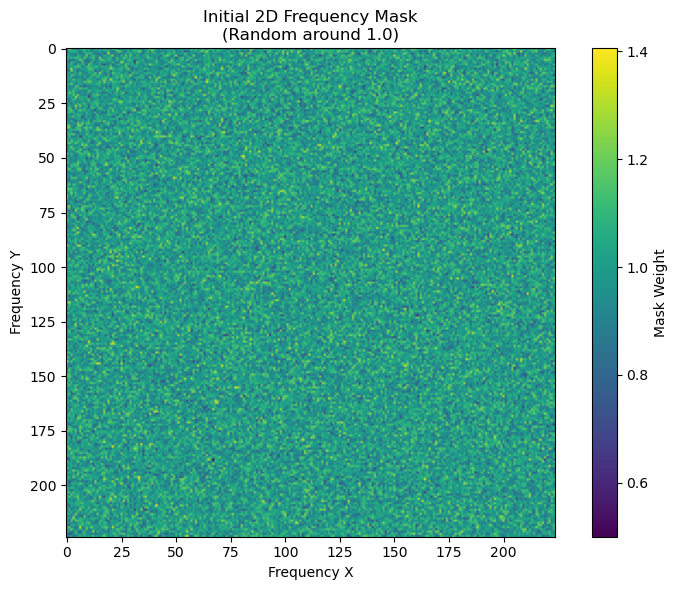

Initial mask statistics:
  Mean: 1.0000
  Std:  0.1001


In [8]:
initial_mask = pipeline.get_mask_visualization()

plt.figure(figsize=(8, 6))
plt.imshow(initial_mask, cmap='viridis')
plt.colorbar(label='Mask Weight')
plt.title('Initial 2D Frequency Mask\n(Random around 1.0)', fontsize=12)
plt.xlabel('Frequency X')
plt.ylabel('Frequency Y')
plt.tight_layout()
plt.show()

print(f"Initial mask statistics:")
print(f"  Mean: {initial_mask.mean():.4f}")
print(f"  Std:  {initial_mask.std():.4f}")

## 5. Training Configuration

In [9]:
# Training hyperparameters
EPOCHS = 90
MASK_LR = 0.01
CLASSIFIER_LR = 0.001
WEIGHT_DECAY = 0.0001
LR_STEP = 30
LR_GAMMA = 0.1

# Optimizer with different learning rates
optimizer = optim.Adam([
    {'params': pipeline.get_mask_params(), 'lr': MASK_LR},
    {'params': pipeline.get_classifier_params(), 'lr': CLASSIFIER_LR}
], weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

criterion = nn.CrossEntropyLoss()

print("Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Mask LR: {MASK_LR}")
print(f"  Classifier LR: {CLASSIFIER_LR}")
print(f"  LR decay: x{LR_GAMMA} every {LR_STEP} epochs")

Training Configuration:
  Epochs: 90
  Batch size: 64
  Mask LR: 0.01
  Classifier LR: 0.001
  LR decay: x0.1 every 30 epochs


## 6. Setup Results Directory

In [14]:
RESULTS_DIR = Path(PROJECT_ROOT) / "experiments" / "results" / "resnet18_phase2.1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: /home/bab61wot/VIT/SIM2REAL/experiments/results/resnet18_phase2.1


## 7. Training Loop

Saves checkpoints after each epoch - can resume if interrupted.

In [15]:
# Training history
history = {'train_loss': [], 'train_acc': []}
best_acc = 0.0
start_epoch = 0

# Check for existing checkpoint
checkpoint_path = RESULTS_DIR / "checkpoint.pt"
if checkpoint_path.exists():
    print("Found existing checkpoint. Loading...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    pipeline.load_state_dict(checkpoint['pipeline_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch']
    best_acc = checkpoint['best_acc']
    history = checkpoint['history']
    print(f"Resumed from epoch {start_epoch}, best_acc={best_acc:.2f}%")
else:
    print("Starting fresh training")

print(f"\nTraining for {EPOCHS} epochs (starting from {start_epoch})...")
print("=" * 60)

Starting fresh training

Training for 90 epochs (starting from 0)...


In [16]:
# Main training loop
for epoch in range(start_epoch, EPOCHS):
    epoch_start = time.time()
    pipeline.train()
    
    epoch_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = pipeline(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if batch_idx % 10 == 0:
            pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{100.0*correct/total:.2f}%"})
    
    scheduler.step()
    
    # Epoch summary
    epoch_time = time.time() - epoch_start
    avg_loss = epoch_loss / len(dataloader)
    accuracy = 100.0 * correct / total
    
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(accuracy)
    
    print(f"\nEpoch {epoch+1}/{EPOCHS} ({epoch_time:.1f}s)")
    print(f"  Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"  LR: mask={optimizer.param_groups[0]['lr']:.6f}, classifier={optimizer.param_groups[1]['lr']:.6f}")
    
    # Save checkpoint
    is_best = accuracy > best_acc
    if is_best:
        best_acc = accuracy
        print(f"  ** New best accuracy: {best_acc:.2f}% **")
    
    torch.save({
        'epoch': epoch + 1,
        'pipeline_state_dict': pipeline.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_acc': best_acc,
        'history': history
    }, checkpoint_path)
    
    if is_best:
        torch.save({'pipeline_state_dict': pipeline.state_dict(), 'best_acc': best_acc}, 
                   RESULTS_DIR / "best_model.pt")
    
    # Visualize mask every 10 epochs
    if (epoch + 1) % 10 == 0:
        mask_viz = pipeline.get_mask_visualization()
        plt.figure(figsize=(8, 6))
        plt.imshow(mask_viz, cmap='RdBu_r', vmin=0.5, vmax=1.5)
        plt.colorbar(label='Mask Weight')
        plt.title(f'Learned Mask - Epoch {epoch+1}')
        plt.savefig(RESULTS_DIR / f"mask_epoch_{epoch+1}.png", dpi=150, bbox_inches='tight')
        plt.show()
    
    print("-" * 60)

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print(f"Best Accuracy: {best_acc:.2f}%")
print("=" * 60)

Epoch 1/90:  13%|████▏                            | 49/391 [00:25<02:57,  1.93it/s, loss=0.0289, acc=99.96%]


KeyboardInterrupt: 

## 8. Visualize Training History

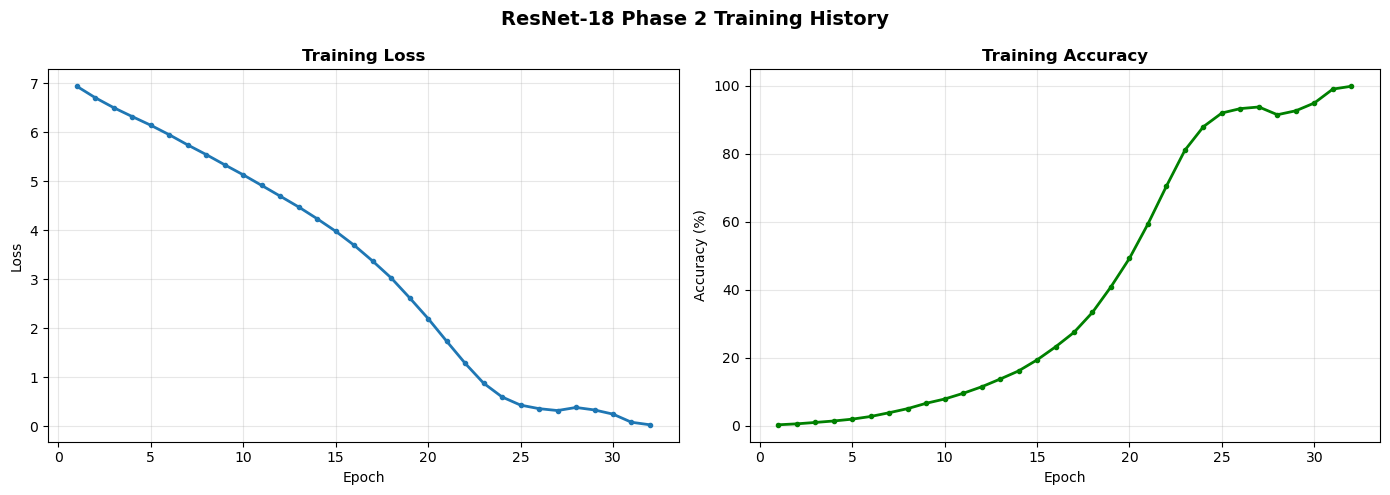

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], marker='o', markersize=3, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], marker='o', markersize=3, linewidth=2, color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet-18 Phase 2 Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_history.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualize Learned Frequency Mask

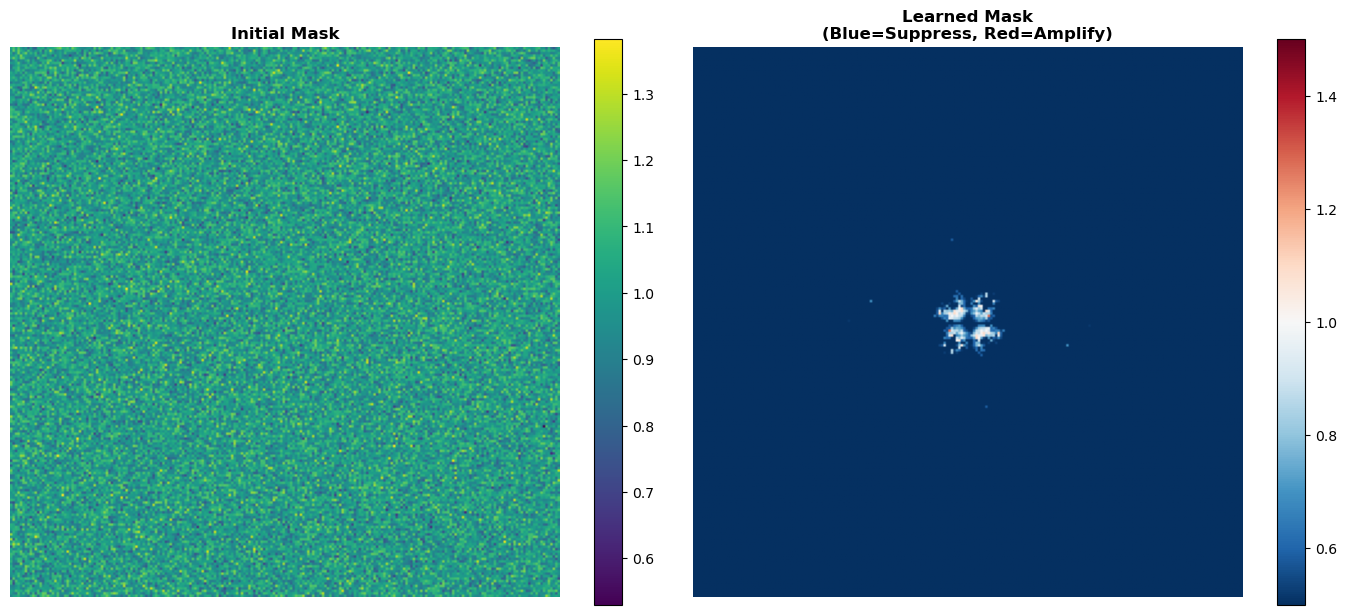


Frequency preference:
  Center (low freq): 0.2081
  Edges (high freq): 0.0000
  Ratio (low/high): 7898.72
  Preference: Low frequencies


In [14]:
learned_mask = pipeline.get_mask_visualization()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

im1 = ax1.imshow(initial_mask, cmap='viridis')
ax1.set_title('Initial Mask', fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(learned_mask, cmap='RdBu_r', vmin=0.5, vmax=1.5)
ax2.set_title('Learned Mask\n(Blue=Suppress, Red=Amplify)', fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "learned_mask.png", dpi=150, bbox_inches='tight')
plt.show()

# Frequency preference analysis
center = learned_mask[112-20:112+20, 112-20:112+20].mean()
edges = np.concatenate([learned_mask[0:20, :].flatten(), learned_mask[-20:, :].flatten(),
                        learned_mask[:, 0:20].flatten(), learned_mask[:, -20:].flatten()]).mean()

print(f"\nFrequency preference:")
print(f"  Center (low freq): {center:.4f}")
print(f"  Edges (high freq): {edges:.4f}")
print(f"  Ratio (low/high): {center/edges:.2f}")
print(f"  Preference: {'Low frequencies' if center > edges else 'High frequencies'}")

## 10. Compare with Phase 1 Results

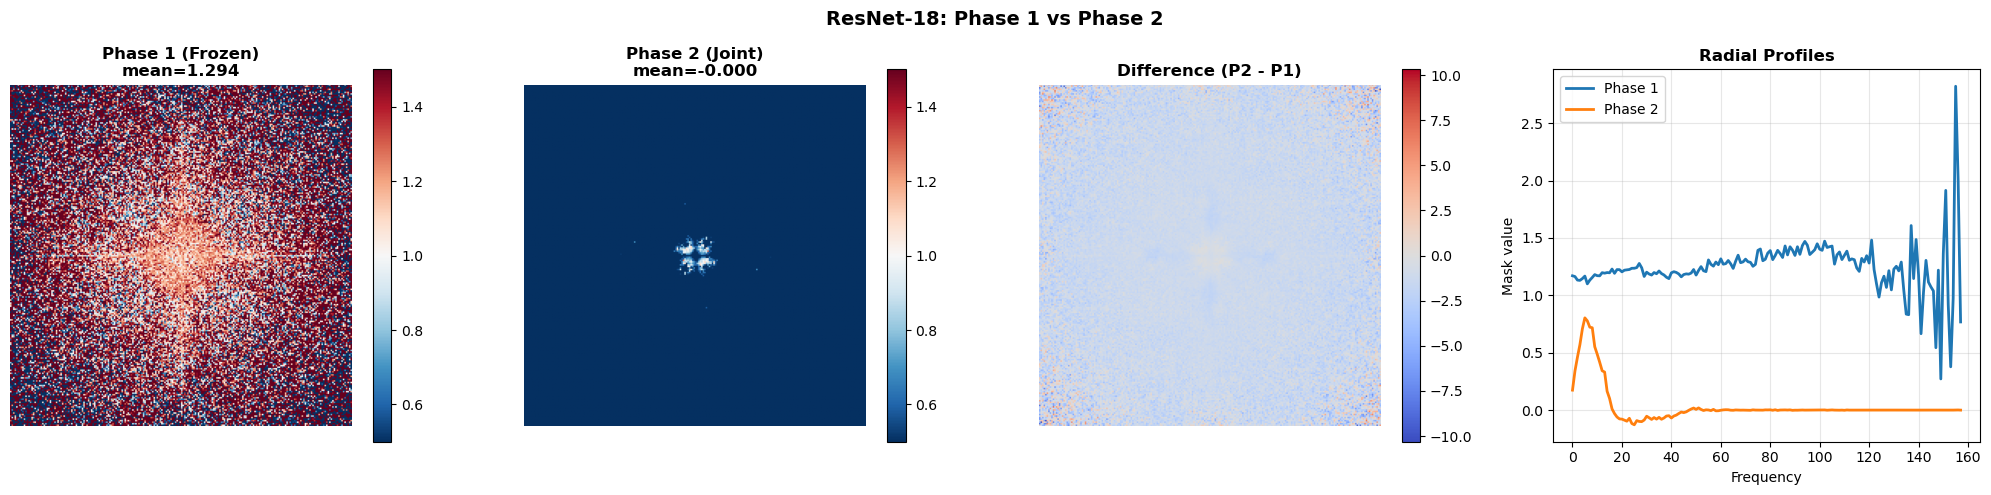


Phase 1 vs Phase 2 Analysis:
  Mask correlation: -0.0003
  -> LOW correlation: Frequency preference is LEARNED from data


In [15]:
phase1_dir = Path(PROJECT_ROOT) / "experiments" / "results" / "resnet18"
phase1_mask_path = phase1_dir / "learned_mask.pt"

if phase1_mask_path.exists():
    phase1_mask_module = Learnable2DFrequencyMask(image_size=224)
    phase1_mask_module.load_state_dict(torch.load(phase1_mask_path, map_location='cpu'))
    phase1_mask = phase1_mask_module.get_mask_visualization()
    phase2_mask = learned_mask
    diff = phase2_mask - phase1_mask
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    im0 = axes[0].imshow(phase1_mask, cmap='RdBu_r', vmin=0.5, vmax=1.5)
    axes[0].set_title(f'Phase 1 (Frozen)\nmean={phase1_mask.mean():.3f}', fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(phase2_mask, cmap='RdBu_r', vmin=0.5, vmax=1.5)
    axes[1].set_title(f'Phase 2 (Joint)\nmean={phase2_mask.mean():.3f}', fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])
    
    vmax = max(abs(diff.min()), abs(diff.max()))
    im2 = axes[2].imshow(diff, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    axes[2].set_title('Difference (P2 - P1)', fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])
    
    # Radial profiles
    def radial_profile(mask):
        h, w = mask.shape
        cy, cx = h // 2, w // 2
        y, x = np.ogrid[:h, :w]
        r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
        r_max = int(np.sqrt(cx ** 2 + cy ** 2))
        return [mask[(r >= rad) & (r < rad + 1)].mean() for rad in range(r_max) if ((r >= rad) & (r < rad + 1)).sum() > 0]
    
    axes[3].plot(radial_profile(phase1_mask), label='Phase 1', linewidth=2)
    axes[3].plot(radial_profile(phase2_mask), label='Phase 2', linewidth=2)
    axes[3].set_xlabel('Frequency')
    axes[3].set_ylabel('Mask value')
    axes[3].set_title('Radial Profiles', fontweight='bold')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    plt.suptitle('ResNet-18: Phase 1 vs Phase 2', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "phase1_vs_phase2.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Correlation analysis
    correlation = np.corrcoef(phase1_mask.flatten(), phase2_mask.flatten())[0, 1]
    print(f"\nPhase 1 vs Phase 2 Analysis:")
    print(f"  Mask correlation: {correlation:.4f}")
    if correlation > 0.7:
        print("  -> HIGH correlation: Frequency preference is ARCHITECTURAL")
    elif correlation > 0.4:
        print("  -> MODERATE correlation: Mix of architectural and learned")
    else:
        print("  -> LOW correlation: Frequency preference is LEARNED from data")
else:
    print("Phase 1 results not found for comparison")

## 11. Save Results

In [ ]:
torch.save(pipeline.freq_mask.state_dict(), RESULTS_DIR / "learned_mask.pt")
torch.save(history, RESULTS_DIR / "training_history.pt")

with open(RESULTS_DIR / "summary.txt", 'w') as f:
    f.write("ResNet-18 Phase 2 - Joint Training Results\n")
    f.write("=" * 50 + "\n")
    f.write(f"Architecture: ResNet-18 (random init)\n")
    f.write(f"Dataset: {len(dataset):,} images\n")
    f.write(f"Epochs: {EPOCHS}\n")
    f.write(f"Best Accuracy: {best_acc:.2f}%\n")
    f.write(f"Final Accuracy: {history['train_acc'][-1]:.2f}%\n")
    f.write(f"Mask LR: {MASK_LR}\n")
    f.write(f"Classifier LR: {CLASSIFIER_LR}\n")

print("Results saved:")
print(f"  - {RESULTS_DIR / 'learned_mask.pt'}")
print(f"  - {RESULTS_DIR / 'training_history.pt'}")
print(f"  - {RESULTS_DIR / 'summary.txt'}")

## 12. Summary

In [ ]:
print("=" * 60)
print("RESNET-18 PHASE 2 SUMMARY")
print("=" * 60)
print(f"\nExperiment: Joint Training (Mask + Classifier from scratch)")
print(f"\nResults:")
print(f"  Best Accuracy: {best_acc:.2f}%")
print(f"  Final Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"\nArtifacts: {RESULTS_DIR}")
print("\nNext: Run Phase 2 for AlexNet, VGG-16, ResNet-50")